<a href="https://colab.research.google.com/github/Joaoplims/NLP-HandsOn/blob/main/HO02/HO02_NLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
import os

# URL do arquivo TXT no GitHub
github_txt_url = "https://raw.githubusercontent.com/Joaoplims/NLP-HandsOn/refs/heads/main/HO02/headlines.txt"
local_txt_path = "/tmp/headlines.txt" # Salva o arquivo TXT em um caminho temporário

print(f"Tentando baixar o arquivo do GitHub: {github_txt_url}")

try:
    response = requests.get(github_txt_url)
    response.raise_for_status() # Levanta um HTTPError para respostas de status de erro (4xx ou 5xx)

    with open(local_txt_path, 'wb') as f:
        f.write(response.content)
    print(f"Arquivo baixado e salvo localmente em: {local_txt_path}\n")

except requests.exceptions.RequestException as e:
    print(f"Erro ao baixar o arquivo: {e}")
    print("Por favor, verifique se a URL do GitHub está correta e o arquivo existe.")

# Este célula pode ser usado para verificar a existência do arquivo.
if os.path.exists('/tmp/headlines.txt'):
    print(f"Arquivo headlines.txt encontrado em: /tmp/headlines.txt")
else:
    print(f"Arquivo headlines.txt NÃO encontrado em: /tmp/headlines.txt. Verifique o download.")

Tentando baixar o arquivo do GitHub: https://raw.githubusercontent.com/Joaoplims/NLP-HandsOn/refs/heads/main/HO02/headlines.txt
Arquivo baixado e salvo localmente em: /tmp/headlines.txt

Arquivo headlines.txt encontrado em: /tmp/headlines.txt


In [6]:
file_path = '/tmp/headlines.txt'

headlines = []

try:
    with open(file_path, 'r', encoding='utf-8') as f:
        for line in f:
            headlines.append(line.strip()) # .strip() removes leading/trailing whitespace, including newline characters
    print(f"Successfully read {len(headlines)} headlines from '{file_path}'.")
    print("\nFirst 5 headlines:")
    for i, headline in enumerate(headlines[:10]):
        print(f"{i+1}. {headline}")
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found in the current directory ({os.getcwd()}). Please check the file path.")
except Exception as e:
    print(f"An error occurred while reading the file: {e}")

Successfully read 10 headlines from '/tmp/headlines.txt'.

First 5 headlines:
1. Investors unfazed by correction as crypto funds see $154 million inflows
2. Bitcoin, Ethereum prices continue descent, but crypto funds see inflows
3. The surge in euro area inflation during the pandemic: transitory but with upside risks
4. Inflation: why it's temporary and raising interest rates will do more harm than good
5. Will Cryptocurrency Protect Against Inflation?
6. Tweed is a crypto wallet API to add a web3 flavor to any web service
7. Who Created Bitcoin? Learn About The Biggest Cryptos, Including Dogecoin, Big Eyes Coin
8. Cryptocurrency Prices And News: Bitcoin, Cryptos Fall After Silvergate Bank Liquidation News
9. Silvergate Capital To Shut Down, Liquidate Crypto-Friendly Silvergate Bank
10. Dow Jones Rises On Surprise Jump In Jobless Claims; Bitcoin Drops As Crypto Bank Silvergate Crashes 40%


### Text Normalization Pipeline

1.  **Remove caracteres especiais**
2.  **Tokenization**
3.  **Lemmatization**
4.  **Stemming**

In [4]:
# Install necessary libraries
!pip install unidecode

# Download NLTK data
import nltk
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('punkt_tab')
# Removed: nltk.download('rslp') as it's for Portuguese
# Download Scikit-Learn
!pip install -U scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 5.4 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 61.3 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [3]:
import re
from unidecode import unidecode
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer, PorterStemmer

# Initialize lemmatizer and stemmer
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

def normalize_text(text):
    # 1. Remove accents and special characters
    text = unidecode(text) # Remove accents
    text = re.sub(r'[^a-zA-Z\s]', '', text) # Remove special characters, keep letters and spaces
    text = text.lower() # Convert to lowercase

    # 2. Tokenization
    tokens = word_tokenize(text)

    # 3. Lemmatization (using English WordNetLemmatizer)
    lemmas = [lemmatizer.lemmatize(word) for word in tokens]

    # 4. Stemming (using English PorterStemmer)
    stemmed_tokens = [stemmer.stem(word) for word in lemmas] # Apply stemming after lemmatization

    return stemmed_tokens

print("Text normalization function 'normalize_text' created successfully.")

Text normalization function 'normalize_text' created successfully.


#### Demonstration of the `normalize_text` function

In [4]:
example_headline = headlines[2] # Using the third headline for demonstration
print(f"Original headline: {example_headline}")

normalized_example = normalize_text(example_headline)
print(f"Normalized headline: {normalized_example}")

Original headline: The surge in euro area inflation during the pandemic: transitory but with upside risks
Normalized headline: ['the', 'surg', 'in', 'euro', 'area', 'inflat', 'dure', 'the', 'pandem', 'transitori', 'but', 'with', 'upsid', 'risk']


In [5]:
# Criar um novo vetor com todas as manchetes normalizadas
all_normalized_documents = [normalize_text(headline) for headline in headlines]

print(f"Sucesso! Criado o vetor 'all_normalized_documents' com {len(all_normalized_documents)} documentos.")

# Demonstrar os primeiros 5 documentos normalizados
print("\nPrimeiros 10 documentos normalizados:")
for i, doc in enumerate(all_normalized_documents[:10]):
    print(f"{i+1}: {doc}")

Sucesso! Criado o vetor 'all_normalized_documents' com 10 documentos.

Primeiros 10 documentos normalizados:
1: ['investor', 'unfaz', 'by', 'correct', 'a', 'crypto', 'fund', 'see', 'million', 'inflow']
2: ['bitcoin', 'ethereum', 'price', 'continu', 'descent', 'but', 'crypto', 'fund', 'see', 'inflow']
3: ['the', 'surg', 'in', 'euro', 'area', 'inflat', 'dure', 'the', 'pandem', 'transitori', 'but', 'with', 'upsid', 'risk']
4: ['inflat', 'whi', 'it', 'temporari', 'and', 'rais', 'interest', 'rate', 'will', 'do', 'more', 'harm', 'than', 'good']
5: ['will', 'cryptocurr', 'protect', 'against', 'inflat']
6: ['tweed', 'is', 'a', 'crypto', 'wallet', 'api', 'to', 'add', 'a', 'web', 'flavor', 'to', 'ani', 'web', 'servic']
7: ['who', 'creat', 'bitcoin', 'learn', 'about', 'the', 'biggest', 'crypto', 'includ', 'dogecoin', 'big', 'eye', 'coin']
8: ['cryptocurr', 'price', 'and', 'news', 'bitcoin', 'crypto', 'fall', 'after', 'silverg', 'bank', 'liquid', 'news']
9: ['silverg', 'capit', 'to', 'shut', 'down

In [9]:
def build_vocabulary(documents):
    """
    Gera um vocabulário único e ordenado a partir de uma lista de documentos (listas de tokens).
    """
    vocab = set()
    for doc in documents:
        for word in doc:
            vocab.add(word)

    return sorted(list(vocab))

# Gerar o vocabulário a partir do vetor de documentos normalizados
vocabulary = build_vocabulary(all_normalized_documents)

print(f"Vocabulário criado com {len(vocabulary)} palavras únicas.")
print(vocabulary[:85])

Vocabulário criado com 84 palavras únicas.
['a', 'about', 'add', 'after', 'against', 'and', 'ani', 'api', 'area', 'bank', 'big', 'biggest', 'bitcoin', 'but', 'by', 'capit', 'claim', 'coin', 'continu', 'correct', 'crash', 'creat', 'crypto', 'cryptocurr', 'cryptofriendli', 'descent', 'do', 'dogecoin', 'dow', 'down', 'drop', 'dure', 'ethereum', 'euro', 'eye', 'fall', 'flavor', 'fund', 'good', 'harm', 'in', 'includ', 'inflat', 'inflow', 'interest', 'investor', 'is', 'it', 'jobless', 'jone', 'jump', 'learn', 'liquid', 'million', 'more', 'news', 'on', 'pandem', 'price', 'protect', 'rais', 'rate', 'rise', 'risk', 'see', 'servic', 'shut', 'silverg', 'surg', 'surpris', 'temporari', 'than', 'the', 'to', 'transitori', 'tweed', 'unfaz', 'upsid', 'wallet', 'web', 'whi', 'who', 'will', 'with']


In [ ]:
import numpy as np

# 1. Criar um mapeamento de palavra para ndice
word_to_idx = {word: i for i, word in enumerate(vocabulary)}
vocab_size = len(vocabulary)

def get_one_hot(word):
    """
    Gera o vetor one-hot para uma palavra especfica baseada no vocabulrio.
    Usamos dtype=int para garantir que os valores sejam 0 e 1 inteiros.
    """
    vector = np.zeros(vocab_size, dtype=int)
    if word in word_to_idx:
        idx = word_to_idx[word]
        vector[idx] = 1
    return vector

# 2. Demonstrao
print(f"{'Palavra':<15} - {'Pos':<3} - {'Representacaoo One-Hot'}")
print('-' * 60)

# Demonstrando para as primeiras 10 palavras do vocabulrio
for word in vocabulary[:10]:
    idx = word_to_idx[word]
    # Convertendo para lista Python comum para uma visualizao limpa [0, 1, 0...]
    one_hot = get_one_hot(word).tolist()

    # Mostrando apenas uma parte do vetor para no poluir a tela
    vector_str = str(one_hot[:15]).replace(']', ', ...]')
    print(f"{word:<15} - {idx:<3} - {vector_str}")

Palavra         - Pos - Representacaoo One-Hot
------------------------------------------------------------
a               - 0   - [1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...]
about           - 1   - [0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...]
add             - 2   - [0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...]
after           - 3   - [0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...]
against         - 4   - [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...]
and             - 5   - [0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...]
ani             - 6   - [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, ...]
api             - 7   - [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, ...]
area            - 8   - [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, ...]
bank            - 9   - [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ...]


### Representação por Counting Vectors (Term Frequency)

Agora, vamos implementar a função que gera o vetor de contagem para um documento inteiro. Diferente do One-Hot (que indica apenas presença/ausência), o Counting Vector reflete a frequência de cada termo.

In [15]:
def get_counting_vector(normalized_doc, vocabulary, word_to_idx):
    """
    Gera um vetor de contagem para um documento baseado no vocabulário.
    """
    vocab_size = len(vocabulary)
    vector = np.zeros(vocab_size, dtype=int)

    for word in normalized_doc:
        if word in word_to_idx:
            idx = word_to_idx[word]
            vector[idx] += 1 # Incrementa a contagem

    return vector

print("Função 'get_counting_vector' criada com sucesso.")

Função 'get_counting_vector' criada com sucesso.


#### Demonstração com uma manchete real
Vamos usar a terceira manchete (`headlines[2]`), que contém a palavra "the" repetida, para observar a contagem no vetor.

In [16]:
idx_demo = 2
doc_demo = all_normalized_documents[idx_demo]
counting_vector = get_counting_vector(doc_demo, vocabulary, word_to_idx)

print(f"Documento original: {headlines[idx_demo]}")
print(f"Documento normalizado: {doc_demo}")

# 1. Mostrar o vetor COMPLETO para visualização total
print(f"\nRepresentação Counting Vector Completa (Vocabulário de {len(vocabulary)} palavras):")
print(counting_vector.tolist())

# 2. Validar especificamente a palavra 'the'
word_to_check = 'the'
idx_the = word_to_idx[word_to_check]
count_the = counting_vector[idx_the]

print(f"\nValidação:")
print(f"Palavra: '{word_to_check}' | Índice no Vocabulário: {idx_the} | Valor no Vetor: {count_the}")

# 3. Mostrar quais índices estão ativos (diferentes de zero)
print("\nÍndices ativos no vetor (Palavra: Frequência):")
for word in set(doc_demo):
    idx = word_to_idx[word]
    count = counting_vector[idx]
    print(f"- Índice {idx:2} ({word:<12}): {count}")

Documento original: The surge in euro area inflation during the pandemic: transitory but with upside risks
Documento normalizado: ['the', 'surg', 'in', 'euro', 'area', 'inflat', 'dure', 'the', 'pandem', 'transitori', 'but', 'with', 'upsid', 'risk']

Representação Counting Vector Completa (Vocabulário de 84 palavras):
[0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 2, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1]

Validação:
Palavra: 'the' | Índice no Vocabulário: 72 | Valor no Vetor: 2

Índices ativos no vetor (Palavra: Frequência):
- Índice 57 (pandem      ): 1
- Índice 40 (in          ): 1
- Índice  8 (area        ): 1
- Índice 13 (but         ): 1
- Índice 72 (the         ): 2
- Índice 33 (euro        ): 1
- Índice 42 (inflat      ): 1
- Índice 83 (with        ): 1
- Índice 77 (upsid       ): 1
- Índice 63 (risk        ): 1
- Índ

### Representação TF-IDF (Term Frequency - Inverse Document Frequency)

O TF-IDF ajuda a destacar palavras que são frequentes em um documento específico, mas raras no restante do conjunto de dados.

In [17]:
import math

def compute_idf(documents, vocabulary):
    """
    Calcula o valor IDF para cada palavra no vocabulário.
    IDF = log(Total de documentos / Documentos que contêm a palavra)
    """
    N = len(documents)
    idf_dict = {}

    for word in vocabulary:
        # Contar em quantos documentos a palavra aparece
        docs_with_word = sum(1 for doc in documents if word in doc)
        # Usamos log natural. Somamos 1 ao denominador para evitar divisão por zero (smooth_idf)
        idf_dict[word] = math.log(N / (docs_with_word))

    return idf_dict

def get_tfidf_vector(normalized_doc, vocabulary, word_to_idx, idf_dict):
    """
    Gera o vetor TF-IDF para um documento.
    """
    vocab_size = len(vocabulary)
    vector = np.zeros(vocab_size, dtype=float)

    # Pegamos as contagens (TF)
    counts = get_counting_vector(normalized_doc, vocabulary, word_to_idx)

    for word in set(normalized_doc):
        if word in word_to_idx:
            idx = word_to_idx[word]
            tf = counts[idx]
            idf = idf_dict[word]
            vector[idx] = tf * idf

    return vector

# 1. Calcular o IDF global baseado em todas as nossas manchetes
idf_values = compute_idf(all_normalized_documents, vocabulary)

print("Valores IDF calculados com sucesso.")

Valores IDF calculados com sucesso.


#### Demonstração do TF-IDF
Vamos comparar o peso da palavra 'the' (muito comum) com palavras mais específicas na mesma manchete.

In [18]:
idx_demo = 2
doc_demo = all_normalized_documents[idx_demo]
tfidf_vector = get_tfidf_vector(doc_demo, vocabulary, word_to_idx, idf_values)

print(f"Documento: {headlines[idx_demo]}\n")
print(f"{'Palavra':<12} | {'Count (TF)':<10} | {'IDF':<8} | {'TF-IDF':<8}")
print("-" * 50)

# Exibir os valores para algumas palavras da manchete
for word in sorted(set(doc_demo)):
    idx = word_to_idx[word]
    tf = get_counting_vector(doc_demo, vocabulary, word_to_idx)[idx]
    idf = idf_values[word]
    tfidf = tfidf_vector[idx]
    print(f"{word:<12} | {tf:<10} | {idf:.4f} | {tfidf:.4f}")

print(f"\nVetor TF-IDF completo (primeiras 20 posições):\n{tfidf_vector[:20].tolist()}")

Documento: The surge in euro area inflation during the pandemic: transitory but with upside risks

Palavra      | Count (TF) | IDF      | TF-IDF  
--------------------------------------------------
area         | 1          | 2.3026 | 2.3026
but          | 1          | 1.6094 | 1.6094
dure         | 1          | 2.3026 | 2.3026
euro         | 1          | 2.3026 | 2.3026
in           | 1          | 1.6094 | 1.6094
inflat       | 1          | 1.2040 | 1.2040
pandem       | 1          | 2.3026 | 2.3026
risk         | 1          | 2.3026 | 2.3026
surg         | 1          | 2.3026 | 2.3026
the          | 2          | 1.6094 | 3.2189
transitori   | 1          | 2.3026 | 2.3026
upsid        | 1          | 2.3026 | 2.3026
with         | 1          | 2.3026 | 2.3026

Vetor TF-IDF completo (primeiras 20 posições):
[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 2.302585092994046, 0.0, 0.0, 0.0, 0.0, 1.6094379124341003, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]


### Matriz de Co-ocorrência (Janela de Contexto)

A co-ocorrência mede quantas vezes duas palavras aparecem próximas uma da outra dentro de uma janela definida (neste caso, 1 vizinho à esquerda e 1 à direita).

In [19]:
# 1. Criar o Dicionário Global de contagem de co-ocorrências
global_cooccurrence = {}

# 2. Percorrer todos os documentos em all_normalized_documents
for doc in all_normalized_documents:
    # Para cada token, olha para o próximo à direita
    for i in range(len(doc) - 1):
        token_a = doc[i]
        token_b = doc[i+1]

        # Criar uma tupla ordenada para garantir a simetria (relação A-B é igual a B-A)
        pair = tuple(sorted((token_a, token_b)))

        # Adicionar ou atualizar a contagem no dicionário
        if pair in global_cooccurrence:
            global_cooccurrence[pair] += 1
        else:
            global_cooccurrence[pair] = 1

# 3. Print do dicionário contendo {tupla}: contagem
print("Dicionário de Co-ocorrências Global (Pares Simétricos):")
for pair, count in global_cooccurrence.items():
    print(f"{pair}: {count}")

Dicionário de Co-ocorrências Global (Pares Simétricos):
('investor', 'unfaz'): 1
('by', 'unfaz'): 1
('by', 'correct'): 1
('a', 'correct'): 1
('a', 'crypto'): 3
('crypto', 'fund'): 2
('fund', 'see'): 2
('million', 'see'): 1
('inflow', 'million'): 1
('bitcoin', 'ethereum'): 1
('ethereum', 'price'): 1
('continu', 'price'): 1
('continu', 'descent'): 1
('but', 'descent'): 1
('but', 'crypto'): 1
('inflow', 'see'): 1
('surg', 'the'): 1
('in', 'surg'): 1
('euro', 'in'): 1
('area', 'euro'): 1
('area', 'inflat'): 1
('dure', 'inflat'): 1
('dure', 'the'): 1
('pandem', 'the'): 1
('pandem', 'transitori'): 1
('but', 'transitori'): 1
('but', 'with'): 1
('upsid', 'with'): 1
('risk', 'upsid'): 1
('inflat', 'whi'): 1
('it', 'whi'): 1
('it', 'temporari'): 1
('and', 'temporari'): 1
('and', 'rais'): 1
('interest', 'rais'): 1
('interest', 'rate'): 1
('rate', 'will'): 1
('do', 'will'): 1
('do', 'more'): 1
('harm', 'more'): 1
('harm', 'than'): 1
('good', 'than'): 1
('cryptocurr', 'will'): 1
('cryptocurr', 'pro

In [20]:
import numpy as np

# 1. Criar a matriz cooccurrence_matrix preenchida com zeros (tamanho do vocabulário)
vocab_size = len(vocabulary)
cooccurrence_matrix = np.zeros((vocab_size, vocab_size), dtype=int)

# Criar mapeamento de palavra para índice para busca rápida
word_to_idx = {word: i for i, word in enumerate(vocabulary)}

# 2. Acessar cada chave do global_cooccurrence e preencher a matriz
for (token_a, token_b), count in global_cooccurrence.items():
    # Identificar o índice do Token A e Token B
    idx_a = word_to_idx[token_a]
    idx_b = word_to_idx[token_b]

    # Atribuir o valor na matriz (garantindo simetria)
    cooccurrence_matrix[idx_a, idx_b] = count
    cooccurrence_matrix[idx_b, idx_a] = count

print("Matriz de Co-ocorrência criada com sucesso.")


Matriz de Co-ocorrência criada com sucesso.


#### Demonstração de Co-ocorrência
Vamos ver quais palavras mais co-ocorrem com termos chave como 'bitcoin' ou 'crypto'.

In [21]:
import pandas as pd

# Criar um DataFrame do pandas para visualizar a matriz como um grid numérico rotulado
cooc_df = pd.DataFrame(cooccurrence_matrix, index=vocabulary, columns=vocabulary)

# Exibir apenas uma parte da matriz (ex: as primeiras 20 palavras) para não sobrecarregar a tela
# Se quiser ver tudo, basta usar display(cooc_df)
display(cooc_df.iloc[:20, :20])

,a,about,add,after,against,and,ani,api,area,bank,big,biggest,bitcoin,but,by,capit,claim,coin,continu,correct
a,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
about,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
add,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
after,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
against,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
and,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
ani,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
api,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
area,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
bank,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


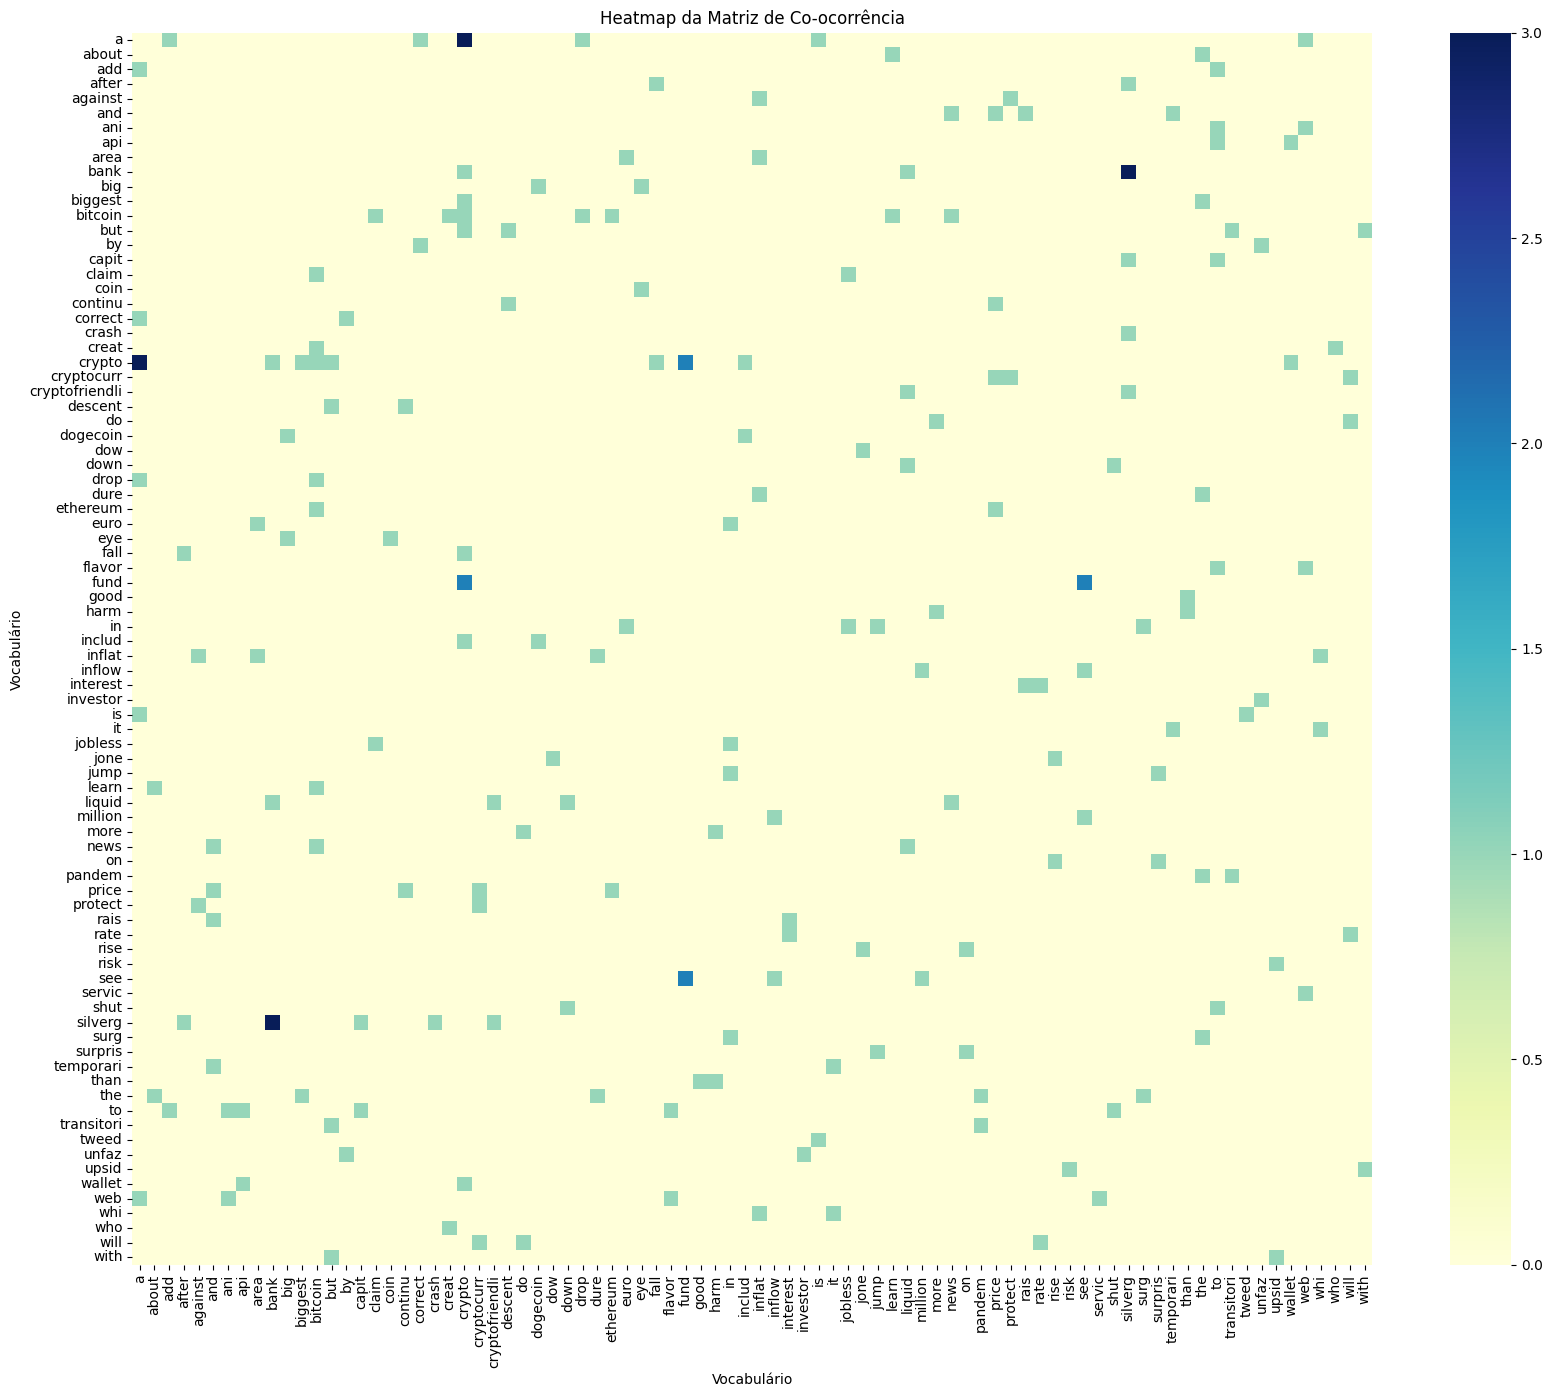

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

# Configurar o tamanho da figura para que as labels fiquem legíveis
plt.figure(figsize=(20, 16))

# Criar o heatmap
# xticklabels e yticklabels usam o nosso vocabulário para identificar as linhas e colunas
sns.heatmap(cooccurrence_matrix,
            annot=False,
            cmap='YlGnBu',
            xticklabels=vocabulary,
            yticklabels=vocabulary)

plt.title('Heatmap da Matriz de Co-ocorrência')
plt.xlabel('Vocabulário')
plt.ylabel('Vocabulário')
plt.show()

### Implementação de Word2Vec (CBOW e Skip-gram)

Utilizaremos a biblioteca `gensim` para transformar nossas palavras em vetores densos (embeddings).

**Parâmetros utilizados:**
- `vector_size=50`: Cada palavra será representada por um vetor de 50 dimensões.
- `window=5`: O contexto considerará 5 palavras vizinhas.
- `min_count=1`: Não descartaremos palavras por baixa frequência, dado o tamanho reduzido do corpus.
- `sg`: Define o algoritmo (0 para CBOW, 1 para Skip-gram).

In [23]:
# Instalar biblioteca necessária
!pip install gensim

from gensim.models import Word2Vec

# 1. Função para treinar usando CBOW (sg=0)
def train_cbow(docs):
    model = Word2Vec(sentences=docs, vector_size=50, window=5, min_count=1, sg=0, workers=4)
    return model

# 2. Função para treinar usando Skip-gram (sg=1)
def train_skipgram(docs):
    model = Word2Vec(sentences=docs, vector_size=50, window=5, min_count=1, sg=1, workers=4)
    return model

# Gerando e armazenando os resultados em variáveis diferentes
model_cbow = train_cbow(all_normalized_documents)
model_skipgram = train_skipgram(all_normalized_documents)

print("Modelos Word2Vec (CBOW e Skip-gram) gerados e armazenados com sucesso!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 48.4 MB/s eta 0:00:00
Modelos Word2Vec (CBOW e Skip-gram) gerados e armazenados com sucesso!


#### Exploração Inicial dos Vetores
Vamos visualizar o vetor gerado para a palavra 'bitcoin' em ambos os modelos.

In [24]:
palavra_teste = 'bitcoin'

print(f"Vetor de '{palavra_teste}' no modelo CBOW:")
print(model_cbow.wv[palavra_teste])

print(f"\nVetor de '{palavra_teste}' no modelo Skip-gram:")
print(model_skipgram.wv[palavra_teste])

# Exemplo de busca por similaridade no CBOW
print(f"\nPalavras mais similares a '{palavra_teste}' no CBOW:")
display(model_cbow.wv.most_similar(palavra_teste, topn=5))
# Exemplo de busca por similaridade no Skip-gram
print(f"\nPalavras mais similares a '{palavra_teste}' no Skip-gram:")
display(model_skipgram.wv.most_similar(palavra_teste, topn=5))

Vetor de 'bitcoin' no modelo CBOW:
[-0.01722436  0.0073385   0.01038028  0.0114864   0.0149234  -0.01233635
  0.00221199  0.01211565 -0.00567309 -0.01236021 -0.00082182 -0.01674785
 -0.01119509  0.01422798  0.00668608  0.01445428  0.01360311  0.01506952
 -0.00758901 -0.00111136  0.00469514 -0.0090262   0.01678199 -0.01970989
  0.01353228  0.00582948 -0.00986529  0.00880505 -0.00348085  0.01342793
  0.01991367 -0.00872883 -0.0012012  -0.01139779  0.00769312  0.00558254
  0.01378616  0.01219773  0.01908217  0.0185571   0.01580409 -0.01398703
 -0.0183125  -0.00071867 -0.00618595  0.01578381  0.01187113 -0.00309866
  0.00302655  0.00357517]

Vetor de 'bitcoin' no modelo Skip-gram:
[-0.01723018  0.00729765  0.01035043  0.01148347  0.01493112 -0.01231979
  0.00220222  0.01211338 -0.00568406 -0.01236336 -0.00084234 -0.01677981
 -0.0111451   0.01425521  0.0066594   0.01447824  0.01360582  0.01509123
 -0.00760685 -0.00113268  0.00473817 -0.00904441  0.01677582 -0.01974108
  0.01351557  0.005825

[('with', 0.3408934772014618),
 ('it', 0.32600295543670654),
 ('million', 0.28945398330688477),
 ('coin', 0.250986784696579),
 ('fall', 0.24869656562805176)]


Palavras mais similares a 'bitcoin' no Skip-gram:


[('with', 0.3412168323993683),
 ('it', 0.32629498839378357),
 ('million', 0.2894674241542816),
 ('coin', 0.2516915500164032),
 ('fall', 0.24915993213653564)]

# Calculo de distancia par a par

## Representação One-Hot

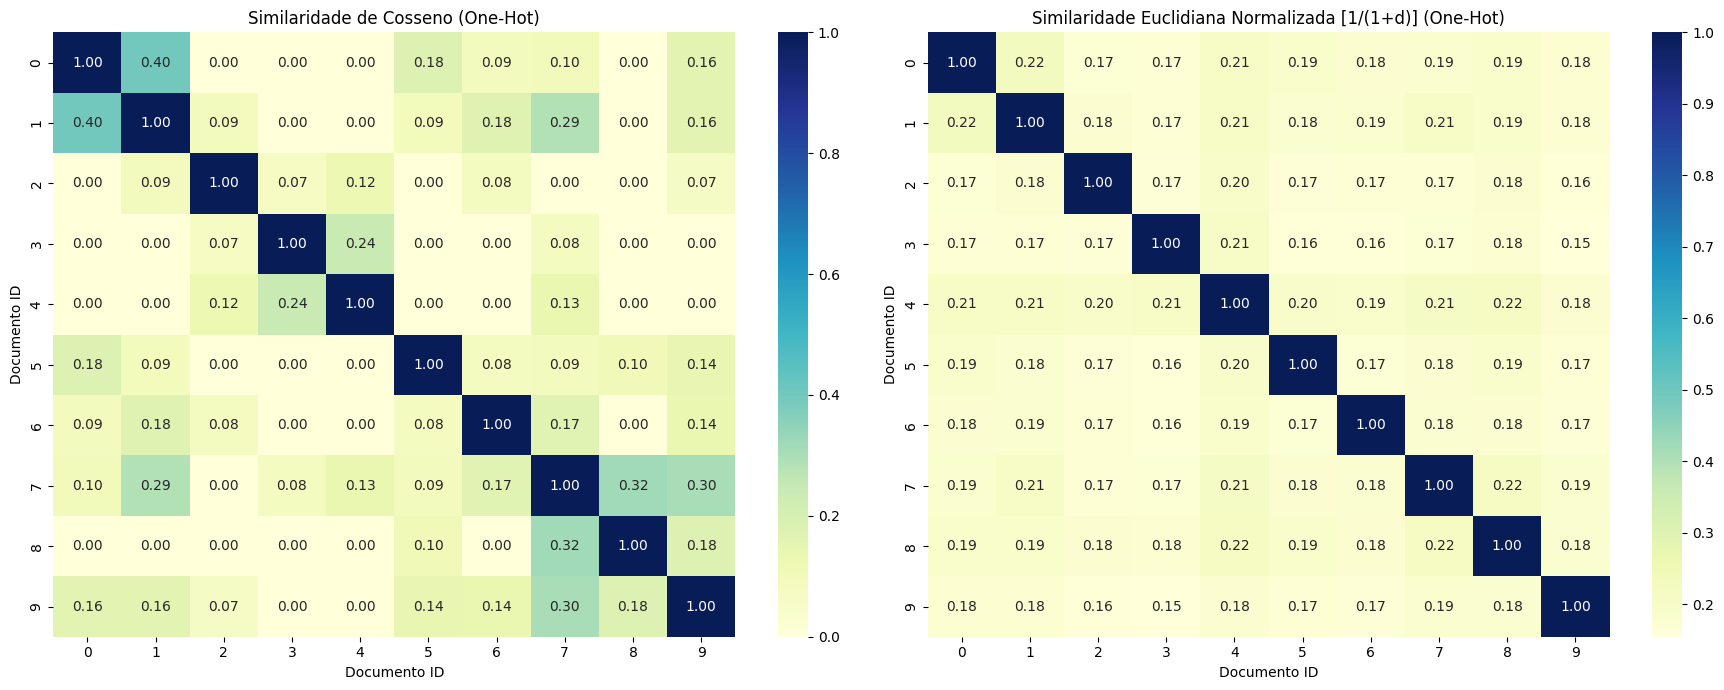

In [27]:
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Gerar a matriz One-Hot para todos os documentos
# Cada linha representa um documento, cada coluna uma palavra do vocabulário
one_hot_matrix = np.zeros((len(all_normalized_documents), len(vocabulary)))

for i, doc in enumerate(all_normalized_documents):
    for word in doc:
        if word in word_to_idx:
            one_hot_matrix[i, word_to_idx[word]] = 1

# 2. Calcular Similaridade de Cosseno
cos_sim_matrix = cosine_similarity(one_hot_matrix)

# 3. Calcular Distância Euclidiana e Normalizar (1 / (1 + d))
euc_dist_matrix = euclidean_distances(one_hot_matrix)
euc_sim_matrix = 1 / (1 + euc_dist_matrix)

# 4. Plotar os Heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap Cosseno
sns.heatmap(cos_sim_matrix, annot=True, fmt=".2f", cmap='YlGnBu', ax=ax1)
ax1.set_title('Similaridade de Cosseno (One-Hot)')
ax1.set_xlabel('Documento ID')
ax1.set_ylabel('Documento ID')

# Heatmap Euclidiano Normalizado
sns.heatmap(euc_sim_matrix, annot=True, fmt=".2f", cmap='YlGnBu', ax=ax2)
ax2.set_title('Similaridade Euclidiana Normalizada [1/(1+d)] (One-Hot)')
ax2.set_xlabel('Documento ID')
ax2.set_ylabel('Documento ID')

plt.tight_layout()
plt.show()

## Representação Counting Vectors (Term Frequency)

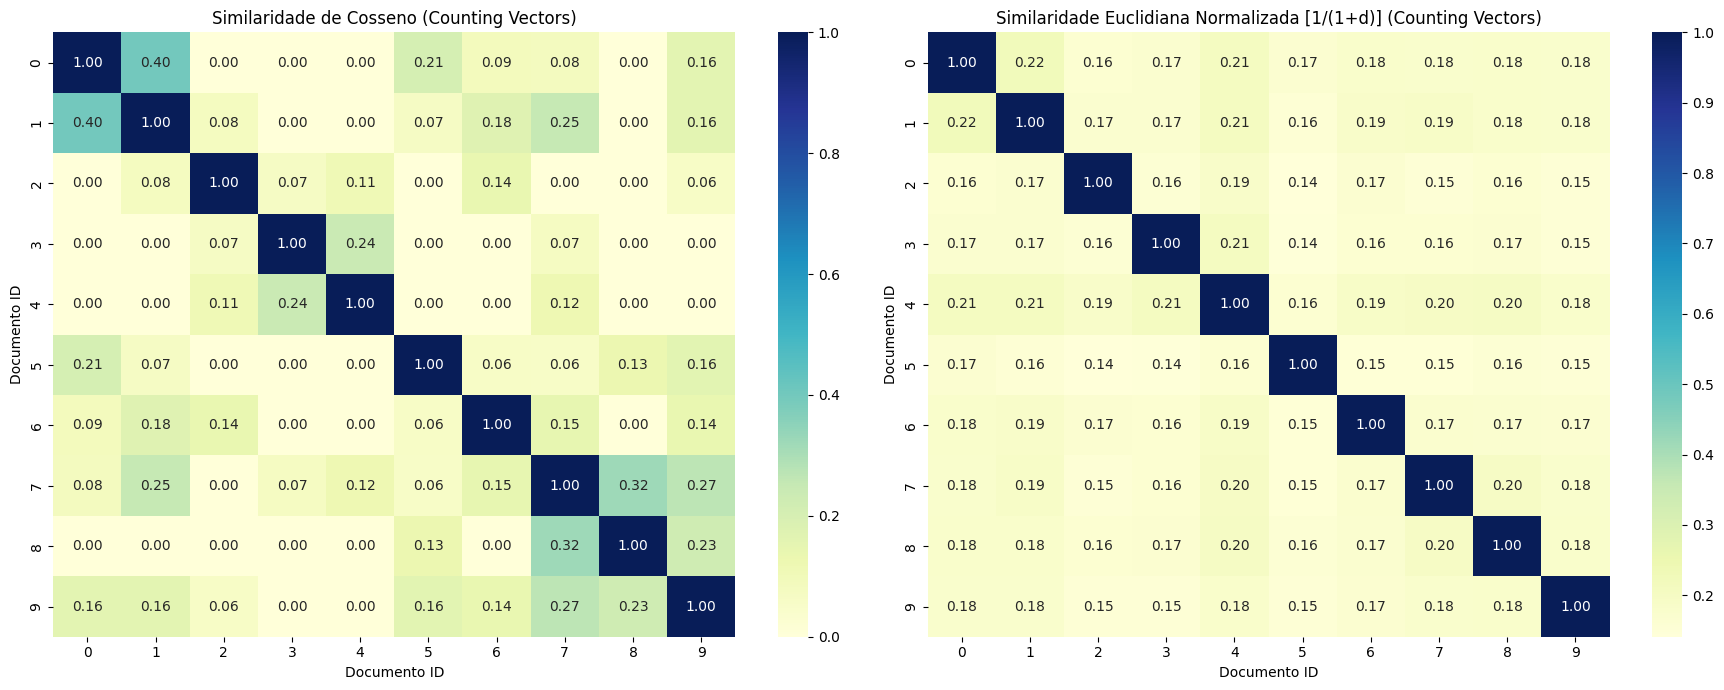

In [28]:
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Gerar a matriz de contagem (Counting Vectors) para todos os documentos
counting_matrix = np.array([get_counting_vector(doc, vocabulary, word_to_idx) for doc in all_normalized_documents])

# 2. Calcular Similaridade de Cosseno
cos_sim_counting = cosine_similarity(counting_matrix)

# 3. Calcular Distância Euclidiana e Normalizar (1 / (1 + d))
euc_dist_counting = euclidean_distances(counting_matrix)
euc_sim_counting = 1 / (1 + euc_dist_counting)

# 4. Plotar os Heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap Cosseno
sns.heatmap(cos_sim_counting, annot=True, fmt=".2f", cmap='YlGnBu', ax=ax1)
ax1.set_title('Similaridade de Cosseno (Counting Vectors)')
ax1.set_xlabel('Documento ID')
ax1.set_ylabel('Documento ID')

# Heatmap Euclidiano Normalizado
sns.heatmap(euc_sim_counting, annot=True, fmt=".2f", cmap='YlGnBu', ax=ax2)
ax2.set_title('Similaridade Euclidiana Normalizada [1/(1+d)] (Counting Vectors)')
ax2.set_xlabel('Documento ID')
ax2.set_ylabel('Documento ID')

plt.tight_layout()
plt.show()

## Representação TF-IDF:

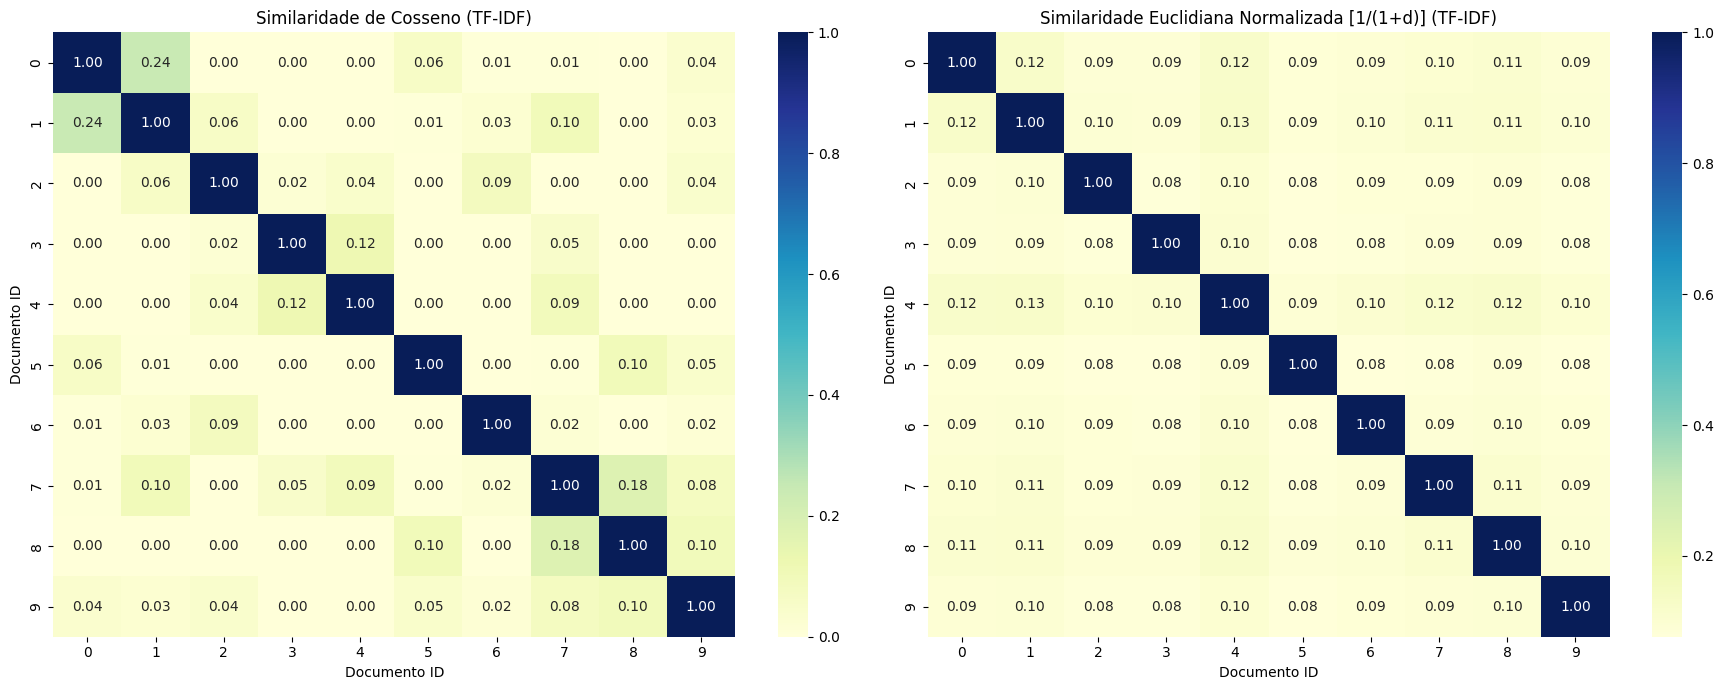

In [29]:
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Gerar a matriz TF-IDF para todos os documentos
tfidf_matrix = np.array([get_tfidf_vector(doc, vocabulary, word_to_idx, idf_values) for doc in all_normalized_documents])

# 2. Calcular Similaridade de Cosseno
cos_sim_tfidf = cosine_similarity(tfidf_matrix)

# 3. Calcular Distância Euclidiana e Normalizar (1 / (1 + d))
euc_dist_tfidf = euclidean_distances(tfidf_matrix)
euc_sim_tfidf = 1 / (1 + euc_dist_tfidf)

# 4. Plotar os Heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap Cosseno
sns.heatmap(cos_sim_tfidf, annot=True, fmt=".2f", cmap='YlGnBu', ax=ax1)
ax1.set_title('Similaridade de Cosseno (TF-IDF)')
ax1.set_xlabel('Documento ID')
ax1.set_ylabel('Documento ID')

# Heatmap Euclidiano Normalizado
sns.heatmap(euc_sim_tfidf, annot=True, fmt=".2f", cmap='YlGnBu', ax=ax2)
ax2.set_title('Similaridade Euclidiana Normalizada [1/(1+d)] (TF-IDF)')
ax2.set_xlabel('Documento ID')
ax2.set_ylabel('Documento ID')

plt.tight_layout()
plt.show()

## Representação Matriz de Co-ocorrencia

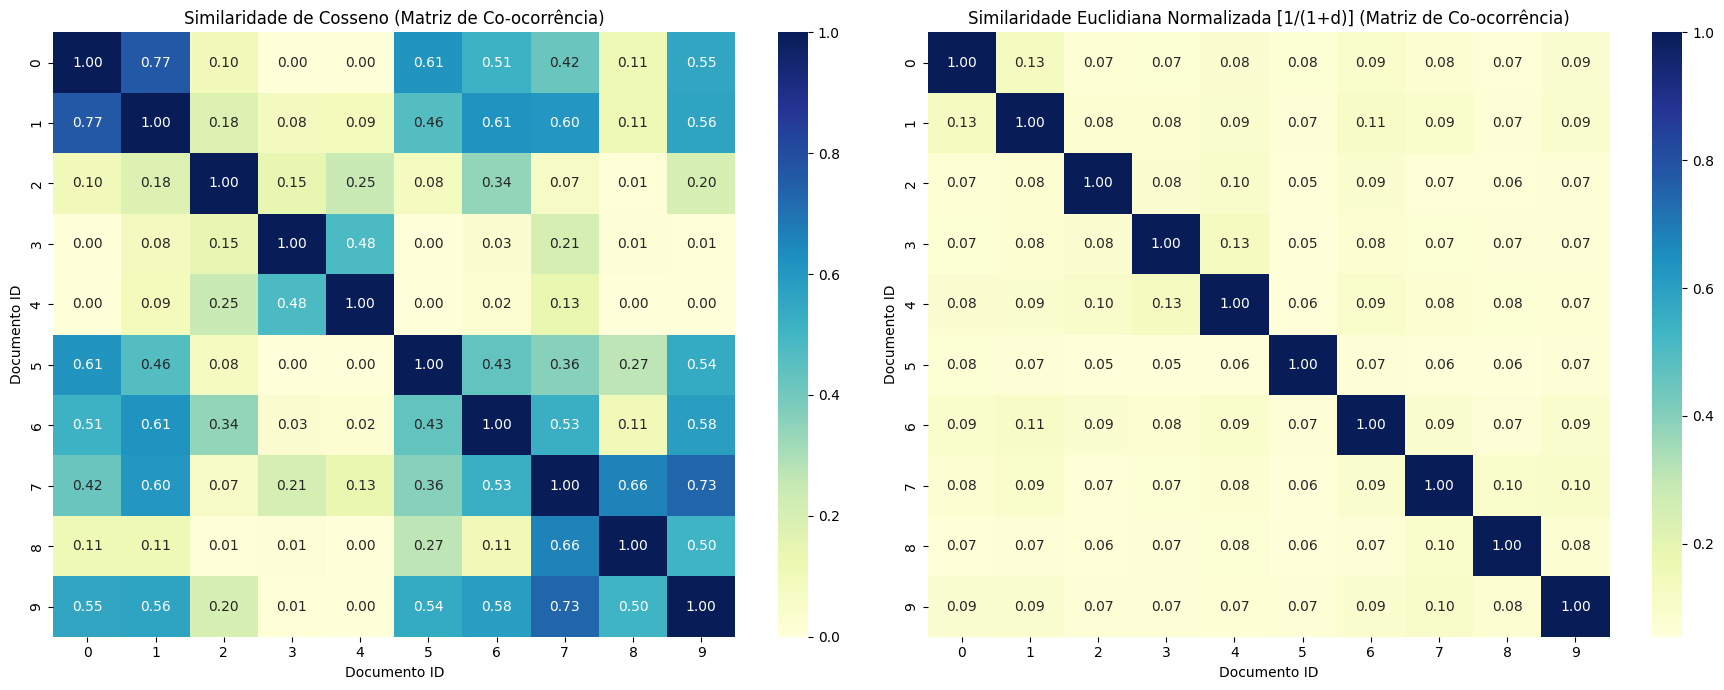

In [30]:
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Gerar vetores de documentos baseados na Matriz de Co-ocorrência
# Para cada documento, somamos os vetores de co-ocorrência das palavras que o compõem
doc_cooc_matrix = []

for doc in all_normalized_documents:
    # Inicializa um vetor de zeros do tamanho do vocabulário
    doc_vector = np.zeros(len(vocabulary))
    for word in doc:
        if word in word_to_idx:
            idx = word_to_idx[word]
            # Soma o vetor da linha correspondente na matriz de co-ocorrência
            doc_vector += cooccurrence_matrix[idx]
    doc_cooc_matrix.append(doc_vector)

doc_cooc_matrix = np.array(doc_cooc_matrix)

# 2. Calcular Similaridade de Cosseno
cos_sim_cooc = cosine_similarity(doc_cooc_matrix)

# 3. Calcular Distância Euclidiana e Normalizar (1 / (1 + d))
euc_dist_cooc = euclidean_distances(doc_cooc_matrix)
euc_sim_cooc = 1 / (1 + euc_dist_cooc)

# 4. Plotar os Heatmaps
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap Cosseno
sns.heatmap(cos_sim_cooc, annot=True, fmt=".2f", cmap='YlGnBu', ax=ax1)
ax1.set_title('Similaridade de Cosseno (Matriz de Co-ocorrência)')
ax1.set_xlabel('Documento ID')
ax1.set_ylabel('Documento ID')

# Heatmap Euclidiano Normalizado
sns.heatmap(euc_sim_cooc, annot=True, fmt=".2f", cmap='YlGnBu', ax=ax2)
ax2.set_title('Similaridade Euclidiana Normalizada [1/(1+d)] (Matriz de Co-ocorrência)')
ax2.set_xlabel('Documento ID')
ax2.set_ylabel('Documento ID')

plt.tight_layout()
plt.show()

## Representação Word2Vec

Visualização para Word2Vec: CBOW


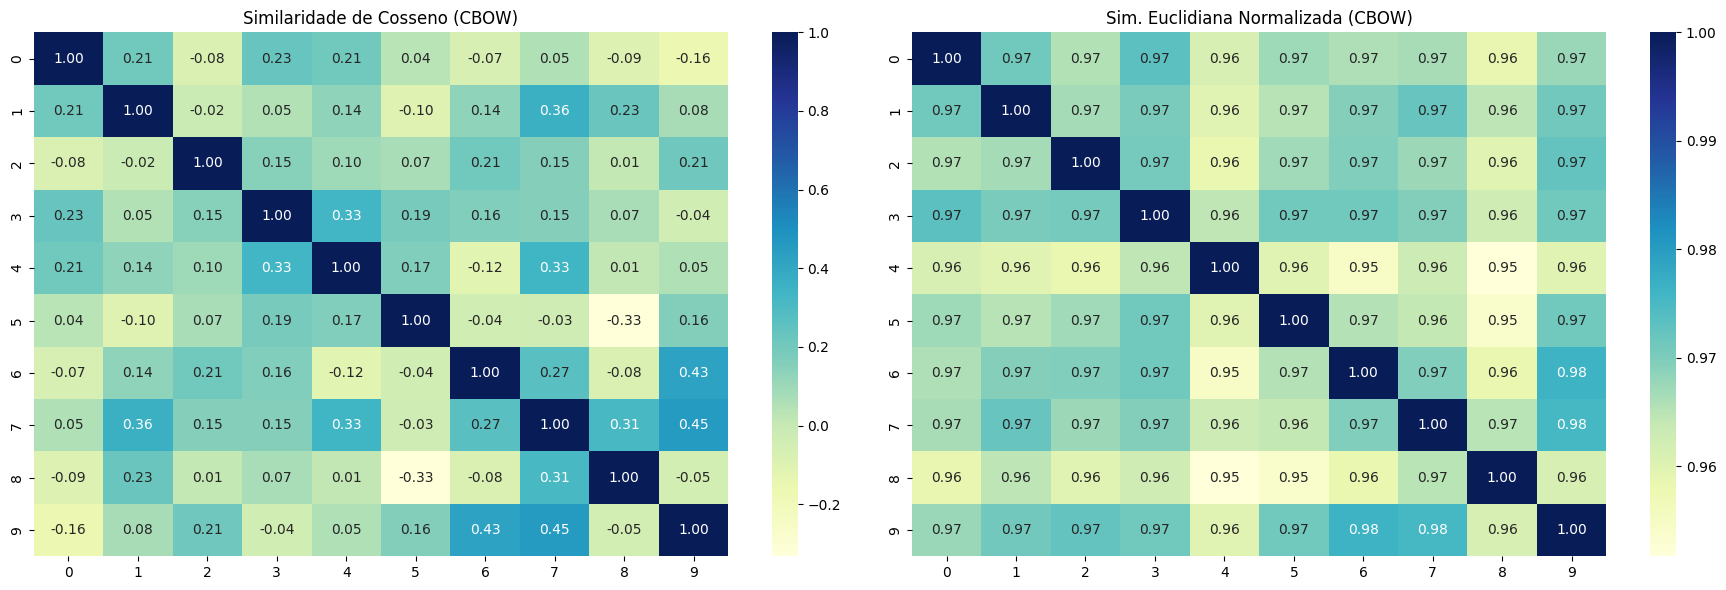


Visualização para Word2Vec: Skip-Gram


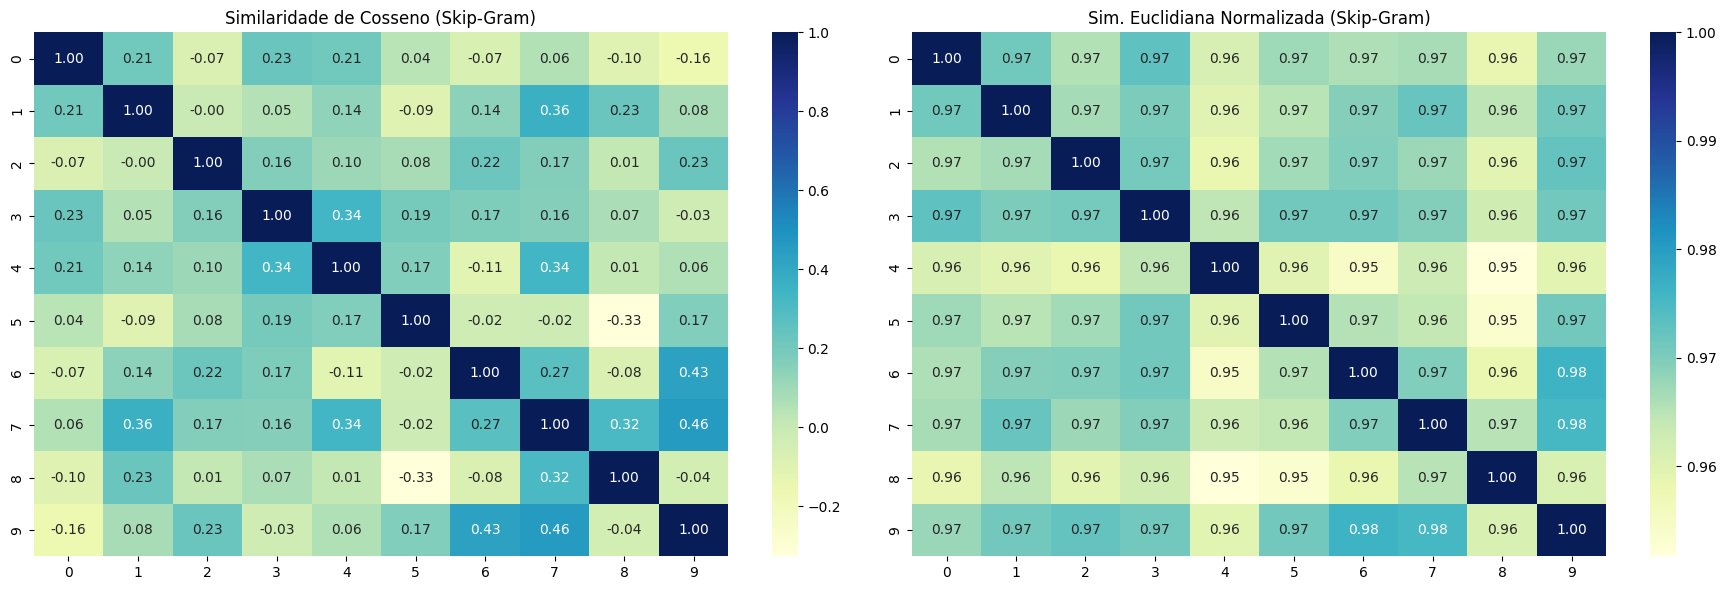

In [31]:
from sklearn.metrics.pairwise import cosine_similarity, euclidean_distances
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def get_document_vector_w2v(doc, model):
    """Gera o vetor do documento tirando a média dos vetores das palavras."""
    vectors = [model.wv[word] for word in doc if word in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)

# 1. Preparar matrizes de documentos para cada modelo
w2v_cbow_matrix = np.array([get_document_vector_w2v(doc, model_cbow) for doc in all_normalized_documents])
w2v_sg_matrix = np.array([get_document_vector_w2v(doc, model_skipgram) for doc in all_normalized_documents])

def plot_w2v_similarities(matrix, title_suffix):
    cos_sim = cosine_similarity(matrix)
    euc_dist = euclidean_distances(matrix)
    euc_sim = 1 / (1 + euc_dist)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

    sns.heatmap(cos_sim, annot=True, fmt=".2f", cmap='YlGnBu', ax=ax1)
    ax1.set_title(f'Similaridade de Cosseno ({title_suffix})')

    sns.heatmap(euc_sim, annot=True, fmt=".2f", cmap='YlGnBu', ax=ax2)
    ax2.set_title(f'Sim. Euclidiana Normalizada ({title_suffix})')

    plt.tight_layout()
    plt.show()

# 2. Plotar para CBOW
print("Visualização para Word2Vec: CBOW")
plot_w2v_similarities(w2v_cbow_matrix, "CBOW")

# 3. Plotar para Skip-Gram
print("\nVisualização para Word2Vec: Skip-Gram")
plot_w2v_similarities(w2v_sg_matrix, "Skip-Gram")

### Interpretação dos Resultados

Ao analisar as matrizes de similaridade, observamos que as representações **One-Hot Encoding**, **Counting Vector** (TF) e **TF-IDF** apresentam, em geral, níveis de similaridade mais baixos. Isso ocorre por alguns motivos fundamentais:

*   **Esparsidade e Semântica:** Nestas técnicas, os vetores são altamente esparsos (predominantemente compostos por zeros) e não capturam relações semânticas latentes. Matematicamente, é como se tivéssemos pontos espalhados em um espaço de altíssima dimensão, porém muito distantes entre si. Como resultado, o alinhamento (cosseno) ou a proximidade (euclidiana) entre quase todos os pares de documentos tende a zero.

*   **Matriz de Co-ocorr1ncia:** Esta representação gera vetores com valores inteiros mais variados (frequências de vizinhança). Ao comparar os documentos, a diversidade desses valores cria uma graduaçao de cores mais rica nos heatmaps, refletindo contextos compartilhados em vez de apenas a presença literal de palavras.

*   **Word2Vec (Embeddings Densos):** Diferente das anteriores, o Word2Vec gera vetores densos (sem zeros), o que significa que os documentos ocupam uma região mais compacta e contínua do espaço vetorial, resultando em heatmaps mais preenchidos ("coloridos").

*   **Escala e Normalização:** Devido ao tamanho reduzido do corpus, os vetores do Word2Vec apresentaram magnitudes muito pequenas (valores entre -0.02 e 0.02). Consequentemente, as distâncias euclidianas brutas sâo mínimas. Ao aplicarmos a normalização $1 / (1 + d)$, esses valores pequenos de distância resultam em similaridades muito próximas de 1, explicando a predominância de cores associadas á alta similaridade nestes gráficos.